# 3 Apr 2026
- basic notebook that samples IPTA MDC1 in principal maps using discovery -- new specspat formalism

In [1]:
import os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
import re
import inspect
import types
import typing
from collections.abc import Iterable
import functools
from pprint import pprint
import time

import numpy as np
import scipy.interpolate as si
import jax
from jax.scipy import stats as jss
import jax.numpy as jnp

from discovery import matrix
from discovery import const
import discovery as ds
import discovery.samplers.numpyro as ds_numpyro
import glob
import discovery.anis_coefficients as dac
import matplotlib.pyplot as plt
from discovery.glgp_specspat import makeglobalgp_fourier_specspat

/home/levis/miniforge3/envs/jhp_disco/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# sampling items
from numpyro import infer, distributions as dist
import numpyro
import scipy.stats as stats
import healpy as hp
from corner import corner
#import maps
import pandas as pd
import pyarrow.feather as feather
import enterprise.signals.anis_coefficients as ac
from PTMCMCSampler import PTMCMCSampler
import matplotlib.patches as mpatches

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
from defiant.extra import mdc1_utils
mdcpsrs, injparams = mdc1_utils.get_MDC1_psrs(use_pickle=True)

## narrowband analysis

In [5]:
# psrs = mdcpsrs
# T = ds.getspan(psrs)
# comps = 6 # freq components
# lmx = 6
# nsi=1

# psrpos = np.array([p.pos for p in psrs])

# lsphorf = dac.get_linspharm_orf(psrpos, lmax=lmx)

# glgp_mdc = makeglobalgp_fourier_specspat(psrs, [ds.powerlaw],
#                                     [[functools.partial(lsphorf, c00=np.sqrt(4*np.pi))]],
#                                     components=comps, T=T, name='gw', nbasis=[[(lmx+1)**2-1]])


# # m_mdc = ds.ArrayLikelihood([ds.PulsarLikelihood([psr.residuals,
# #                                              ds.makenoise_measurement_simple(psr),
# #                                              ds.makegp_timing(psr, svd=True)]) for psr in psrs],
# #                        commongp = ds.makecommongp_fourier(psrs, ds.powerlaw, components=30, T=T, name='rednoise'),
# #                        globalgp = glgp_mdc)

# m_mdc = ds.GlobalLikelihood([ds.PulsarLikelihood([psr.residuals, #ds.makenoise_measurement_simple(psr, noisedict=ndict),
#                                              ds.makenoise_measurement_simple(psr),
#                                              ds.makegp_timing(psr, svd=True),
#                                              ds.makegp_fourier(psr, ds.powerlaw, components=30, name='rednoise')]) for psr in psrs],
#                                              globalgp = glgp_mdc)


# mdc_jlogl = jax.jit(m_mdc.logL)

In [76]:
psrs = mdcpsrs
T = ds.getspan(psrs)
comps = 2 # freq components
nsi=1

ndict = {f'{p.name}_efac': 1.0 for p in psrs}
ndict.update({f'{p.name}_log10_t2equad': -7 for p in psrs})

psrpos = np.array([p.pos for p in psrs])

orflst = []
nanisopars = []
basismaps_lst = []
for i in range(comps):
    pmaporf, basismaps = dac.get_principalmap_pixelbasis_orf(psrpos, perc_sv=0.7)
    orflst.append(pmaporf)
    nanisopars.append(basismaps.shape[0])
    basismaps_lst.append(basismaps)

glgp_mdc = makeglobalgp_fourier_specspat(psrs, [ds.freespectrum],
                                    [orflst],
                                    components=comps, T=T, name='gw', nbasis=[nanisopars])


m_mdc = ds.ArrayLikelihood([ds.PulsarLikelihood([psr.residuals,
                                             ds.makenoise_measurement_simple(psr, noisedict=ndict),
                                             ds.makegp_timing(psr, svd=True)]) for psr in psrs],
                       commongp = ds.makecommongp_fourier(psrs, ds.powerlaw, components=30, T=T, name='rednoise'),
                       globalgp = glgp_mdc)

# m_mdc = ds.GlobalLikelihood([ds.PulsarLikelihood([psr.residuals, #ds.makenoise_measurement_simple(psr, noisedict=ndict),
#                                              ds.makenoise_measurement_simple(psr),
#                                              ds.makegp_timing(psr, svd=True),
#                                              ds.makegp_fourier(psr, ds.powerlaw, components=30, name='rednoise')]) for psr in psrs],
#                                              globalgp = glgp_mdc)


mdc_jlogl = jax.jit(m_mdc.logL)

@jax.jit
def constrn_like(params):
    paramdict = {f'{p.name}_rednoise_gamma':1 for p in mdcpsrs}
    paramdict.update({f'{p.name}_rednoise_log10_A':-18 for p in mdcpsrs})
    for i in range(comps):
        paramdict[f'gw_amps_f{i}({nanisopars[i]})'] = params[nanisopars[i]*i:nanisopars[i]*i+nanisopars[i]]
    paramdict[f'gw_log10_rho({comps})'] = params[-comps:]
    return m_mdc.logL(paramdict)

num_anisopars = np.sum(nanisopars)
nparams = np.sum(nanisopars) + 2

In [74]:
mdc_jlogl.params

['J0030+0451_rednoise_gamma',
 'J0030+0451_rednoise_log10_A',
 'J0218+4232_rednoise_gamma',
 'J0218+4232_rednoise_log10_A',
 'J0437-4715_rednoise_gamma',
 'J0437-4715_rednoise_log10_A',
 'J0613-0200_rednoise_gamma',
 'J0613-0200_rednoise_log10_A',
 'J0621+1002_rednoise_gamma',
 'J0621+1002_rednoise_log10_A',
 'J0711-6830_rednoise_gamma',
 'J0711-6830_rednoise_log10_A',
 'J0751+1807_rednoise_gamma',
 'J0751+1807_rednoise_log10_A',
 'J0900-3144_rednoise_gamma',
 'J0900-3144_rednoise_log10_A',
 'J1012+5307_rednoise_gamma',
 'J1012+5307_rednoise_log10_A',
 'J1022+1001_rednoise_gamma',
 'J1022+1001_rednoise_log10_A',
 'J1024-0719_rednoise_gamma',
 'J1024-0719_rednoise_log10_A',
 'J1045-4509_rednoise_gamma',
 'J1045-4509_rednoise_log10_A',
 'J1455-3330_rednoise_gamma',
 'J1455-3330_rednoise_log10_A',
 'J1600-3053_rednoise_gamma',
 'J1600-3053_rednoise_log10_A',
 'J1603-7202_rednoise_gamma',
 'J1603-7202_rednoise_log10_A',
 'J1640+2224_rednoise_gamma',
 'J1640+2224_rednoise_log10_A',
 'J1643-

In [39]:
def plot_map(pixelvals):
    hp.mollview(pixelvals, rot=180)
    dac.plot_pulsars(mdcpsrs)
    plt.show()

In [40]:
nanisopars

[7, 7]

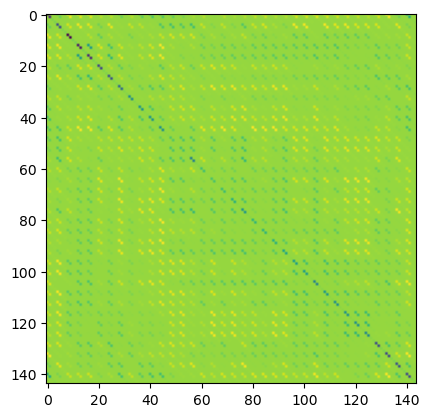

In [41]:
tstdict = {}
tstdict[f'gw_amps_f0({nanisopars[0]})'] = np.ones(nanisopars[0]) * 0.1
tstdict[f'gw_amps_f1({nanisopars[1]})'] = np.ones(nanisopars[1]) * 0.1
tstdict['gw_gamma'] = 13/3
tstdict['gw_log10_A'] = -16

tstphi = m_mdc.globalgp.Phi.getN(tstdict)
tstphiinv = m_mdc.globalgp.Phi_inv(tstdict)[0]
plt.imshow(m_mdc.globalgp.Phi.getN(tstdict))

In [42]:
fullcompbasismaps = np.vstack(basismaps_lst)

In [51]:
fullcompbasismaps.T * randamps

array([[ 0.04974036, -0.00152369, -0.09631876, ..., -0.0044431 ,
        -0.03049702, -0.03320469],
       [ 0.0492132 , -0.00176688, -0.09224332, ..., -0.00457352,
        -0.03229126, -0.0328168 ],
       [ 0.05243484, -0.00109843, -0.09295563, ..., -0.00629595,
        -0.03491952, -0.03552997],
       ...,
       [ 0.06541458, -0.00597102,  0.06701598, ..., -0.04125622,
        -0.00065278, -0.01379264],
       [ 0.06922047, -0.00530639,  0.07162898, ..., -0.04244744,
        -0.00168083, -0.02072386],
       [ 0.06999191, -0.00503082,  0.06717505, ..., -0.04254941,
         0.00681257, -0.02457487]], shape=(3072, 14))

In [ ]:
aniparamct = 0 # LSS we do this in case we do not have the same number of clms for each freq component
clmprival = 0 # LSS a placeholder for the sum of the clm priors
for c in range(comps):
    clvalues = params[aniparamct:aniparamct+nclms[c]]
    clmprival += jnp.sum(clmpri(clvalues))
    aniparamct += nclms[c]

In [52]:
validamps = []
fullcompbasismaps = np.vstack(basismaps_lst)

while len(validamps) < 10:
    randamps = np.random.uniform(low=-5, high=5, size=num_anisopars)
    allmaps = fullcompbasismaps.T * randamps
    invskies = []
    aniparamct = 0
    for i in range(comps):
        smap = allmaps[:, aniparamct:aniparamct+nanisopars[i]]
        aniparamct+=nanisopars[i]
        invskies.append(np.sum(smap, axis=1) < 0)

    invalidsky = np.sum(invskies) > 0 # True if sky has negative values
    if not invalidsky:
        validamps.append(randamps)
        print(len(validamps))

1
2


KeyboardInterrupt: 

In [53]:
validamps

[array([-4.85728699, -1.70395206, -0.16558402,  1.37104623, -0.78575262,
         1.10302884, -0.10405271, -4.82472644, -3.3067222 ,  0.79435669,
         0.23550462,  0.23711775,  0.51095019,  0.52593958]),
 array([-4.4664823 , -0.84499786,  1.50155375,  0.01734097,  2.02011356,
         0.59533677, -0.12560027, -4.36131392, -0.73072347,  0.4076518 ,
        -0.600056  , -2.41289205, -1.80668471, -0.15076899])]

In [77]:
validpars = np.zeros(nparams)
validpars[-comps:] = np.ones(comps) * -6.0
validpars[:nanisopars[0]] = validamps[0][:nanisopars[0]]
validpars[nanisopars[0]:nanisopars[0] + nanisopars[1]] = validamps[0][:nanisopars[1]]
for i in range(10):
    print(constrn_like(validpars))

39302.91866357635
39302.91866357635
39302.91866357635
39302.91866357635
39302.91866357635
39302.91866357635
39302.91866357635
39302.91866357635
39302.91866357635
39302.91866357635


In [67]:
validpars

array([ -4.85728699,  -1.70395206,  -0.16558402,   1.37104623,
        -0.78575262,   1.10302884,  -0.10405271,  -4.85728699,
        -1.70395206,  -0.16558402,   1.37104623,  -0.78575262,
         1.10302884,  -0.10405271,   4.33333333, -16.        ])

In [68]:
%timeit constrn_like(validpars).block_until_ready()

1.98 ms ± 88.8 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [85]:
l10apri = lambda x: jss.uniform.logpdf(x, -18, 6)
gampri = lambda x: jss.uniform.logpdf(x, 0, 7)
amppri = lambda x: jss.uniform.logpdf(x, -5, 10)
rhopri = lambda x: jss.uniform.logpdf(x, -9, 5)


@jax.jit
def priorfunc(params):
    amps = params[:num_anisopars]
    rho = params[-comps:]
    rhoprival = jnp.sum(rhopri(rho))
    ampprival = jnp.sum(amppri(amps))
    fullpri = ampprival + rhoprival

    # LSS physicality prior: check if the sky map has negative values
    allmaps = fullcompbasismaps.T * amps
    invskies = []
    aniparamct = 0
    for i in range(comps):
        smap = basismaps_lst[i].T * amps[aniparamct:aniparamct+nanisopars[i]]
        aniparamct+=nanisopars[i]
        invskies.append(jnp.sum(smap, axis=1) < 0)

    invalidsky = jnp.sum(jnp.array(invskies)) > 0 # True if sky has negative values
    # print(invalidsky)
    ret = jnp.where(invalidsky, -jnp.inf, fullpri)
    return ret

priorfunc(validpars)


Array(-35.45506713, dtype=float64)

In [86]:
%timeit priorfunc(validpars).block_until_ready()

24.7 μs ± 526 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [21]:
prigrad = jax.grad(priorfunc)
likgrad = jax.grad(constrn_like)

# prigradjump = lambda x: (priorfunc(x), prigrad(x))
# prigradlike = lambda x: (constrn_like(x), likgrad(x))

def prigradjump(x):
    return np.float64(priorfunc(x)).item(), np.array(prigrad(x))

def likegradjump(x):
    return np.float64(constrn_like(x)).item(), np.array(likgrad(x))

In [87]:
initcov = np.eye(nparams) * 0.01
sampler = PTMCMCSampler.PTSampler(ndim=nparams, logl=constrn_like, logp=priorfunc,
                                   #logl_grad=likegradjump, logp_grad=prigradjump,
                                   cov=initcov,
                                   outDir='./chains/narrow_pmap/', resume=False)

In [88]:
sampler.sample(Niter=10000, p0=np.array(validpars),
               SCAMweight=25, AMweight=25, DEweight=50)

Finished 100.00 percent in 12.346412 s Acceptance rate = 0.40574
Run Complete


## Looking at the chain

In [89]:
chn = np.loadtxt('/home/levis/ipta_aniso_datachallenge/examples/principalmaps/chains/narrow_pmap/chain_1.txt')

In [90]:
chn.shape

(1001, 20)

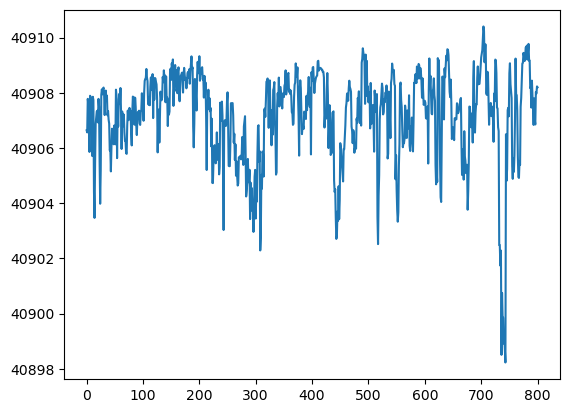

In [94]:
plt.plot(chn[200:, -4])

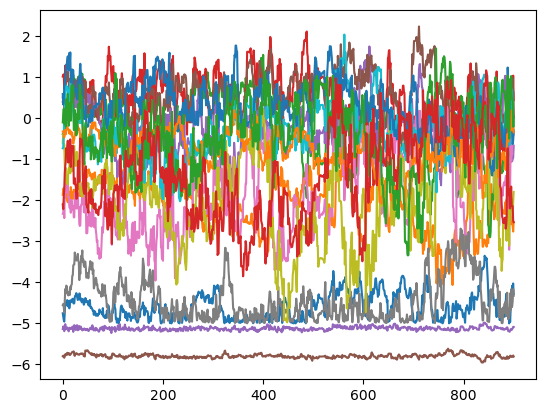

In [95]:
for i in range(nparams):
    plt.plot(chn[100:, i])

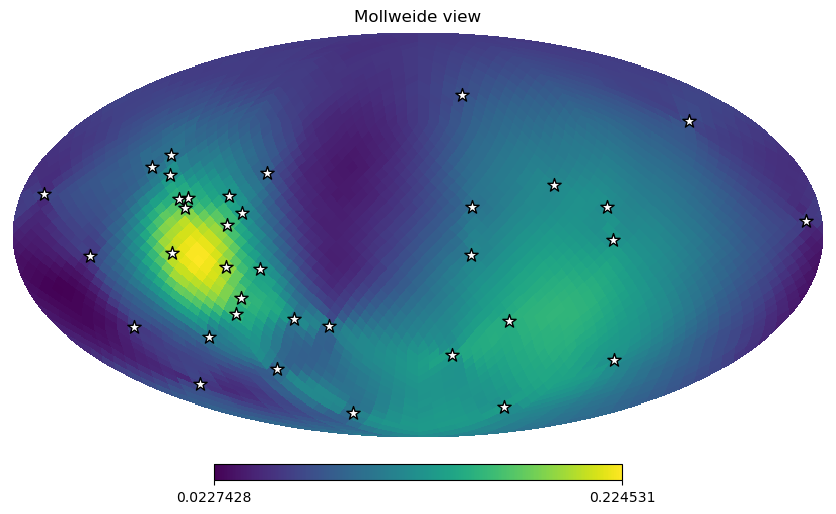

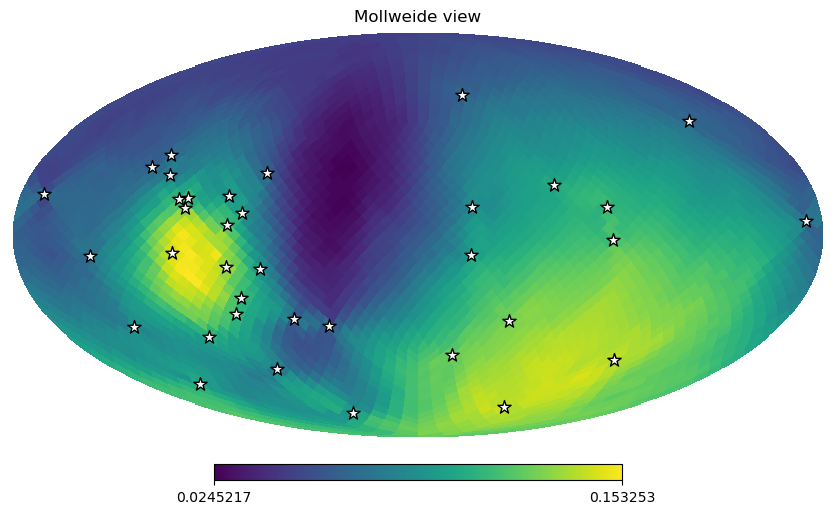

In [97]:
randidx = np.random.randint(200, 1000, size=100)
aniparamct = 0
for i in range(comps):
    plot_map(np.median(basismaps_lst[i].T @ chn[randidx, aniparamct:aniparamct+nanisopars[i]].T, axis=1))
    aniparamct += nanisopars[i]